# 1) GNINA en GoogleColab — Guía Didáctica

>>Este cuaderno ha sido adaptado por el Dr. Abraham Madariaga de versiones hechas por el Dr. Rogelio Rodríguez-Sotres y Dr. Victor M. Palomar-Olguín. Guía basada en la original realizada por los desarrolladores de Gnina y mejorada por medio de GPT.

> **Objetivos de este documento:**
>>(1) instalar/ejecutar GNINA en Colab, (2) definir la caja de búsqueda (autobox o manual), (3) correr *docking* con y sin *CNN rescoring*, (4) interpretar las salidas (Affinity, RMSD, CNNscore, CNNaffinity), y (5) visualizar y exportar resultados.

---

**¿Qué es GNINA?** GNINA es un *fork* de **smina** (a su vez *fork* de AutoDock Vina) que integra **redes convolucionales (CNN)** para re‑puntuar poses y mejorar la selección de conformaciones cuando la cavidad de unión está correctamente definida.

**Referencias clave y recursos (ver lista completa al final):**
- Repositorio oficial: https://github.com/gnina/gnina
- Paper GNINA 1.0 (McNutt *et al.*, 2021, *J. Cheminf.*)
- Paper GNINA 1.3 (McNutt *et al.*, 2025): actualización a Torch + nuevos modelos
- Vina (Trott & Olson, 2010) y smina (Koes *et al.*, 2013)

## 0) Requisitos y entorno

- En Colab: **Entorno de ejecución → Cambiar tipo → GPU** (Tesla T4, A100, etc.).  
- Este cuaderno instala **GNINA** (binario), **Open Babel** (formato/SMILES→3D) y **py3Dmol** (visualización).
- Para ejecución **local** (Linux/Mac/WSL), ver la sección *Apéndice A*.

In [1]:
# @title Verifica GPU disponible (Colab)
!nvidia-smi || true


Mon Mar 23 15:53:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1) Instalar GNINA + utilidades

Debajo se instala una **versión estable reciente** de GNINA. Puedes cambiar `GNINA_TAG` a otra (por ejemplo, `v1.3.2`, `v1.3.1`, `v1.1`).  
Si `wget` no encuentra el binario (o hay incompatibilidad con CUDA/cuDNN), usa la imagen **Docker** oficial (ver *Apéndice A*).


In [2]:
# @title Instalar GNINA (binario estático) + utilidades
# Cambia el tag si lo deseas (e.g., v1.3.2). Ver: https://github.com/gnina/gnina/releases
#GNINA_TAG = "v1.3.2"  #@param {type:"string"}

import os, subprocess, shutil, sys, json, textwrap

def run(cmd):
    print("+", cmd)
    return subprocess.run(cmd, shell=True, check=False)

# Descargar binario de la release
run(f"wget -q https://github.com/gnina/gnina/releases/download/v1.1/gnina -O gnina")
run("chmod +x gnina")
run("./gnina --version || true")

# Herramientas auxiliares
run("apt-get update -y && apt-get install -y openbabel > /dev/null 2>&1")
run("pip -q install py3Dmol pandas > /dev/null 2>&1")


+ wget -q https://github.com/gnina/gnina/releases/download/v1.1/gnina -O gnina
+ chmod +x gnina
+ ./gnina --version || true
+ apt-get update -y && apt-get install -y openbabel > /dev/null 2>&1
+ pip -q install py3Dmol pandas > /dev/null 2>&1


CompletedProcess(args='pip -q install py3Dmol pandas > /dev/null 2>&1', returncode=0)

In [3]:
! pip install rdkit

In [4]:
# @title  Comprobación de que se instaló gnina
!./gnina --version

gnina v1.1 master:e4cb380+   Built Dec 18 2023.


## 2) Cargar el PDB-ID y extraer receptor y ligando(s)

En este ejemplo usaremos calmodulina (CaM) con código **PDB:1A29** complejado con **Trifluoperazina (TFP)**, residuo número **153 y 154**.

RCSB PDB: [1A29](https://www.rcsb.org/structure/1A29)
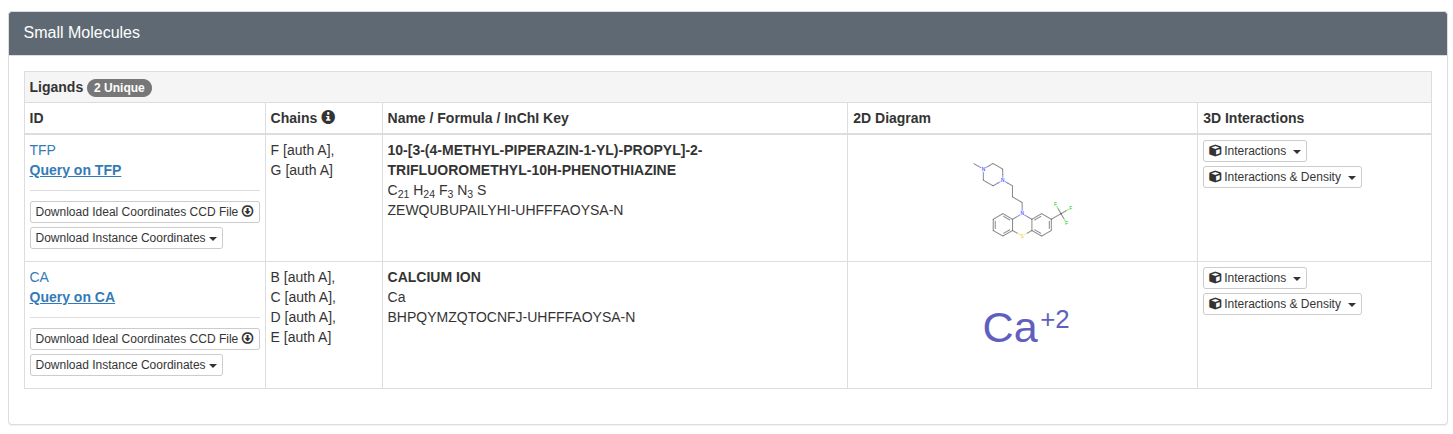

Se obtendrán las salidas:
- protein_*no_lig_no_wat*.pdb  (solo ATOM)
- ligand_*RESN_CHAIN-RESID*.pdb  (ligando o ligandos)

> **Nota:** GNINA acepta `PDB/PDBQT/SDF/MOL2`; para este notebook, mantendremos PDB + *autobox* o caja manual.


In [6]:
#@title Descargar/extraer ligando(s) y proteína limpia desde RCSB { display-mode: "form" }
#@markdown **Instrucciones:** Elije PDB ID, resname del ligando, cadena y resid. Usa `*` en *Cadena* o *Resid* para traer **todas** las instancias del ligando.
PDB_ID   = "8CH8"  #@param {type:"string"}
LIG_RESN = "ULC"   #@param {type:"string"}
CHAIN    = "B"     #@param ["*","A","B","C","D","E","F","G","H","I","J","K","L","M","N","O","P","Q","R","S","T","U","V","W","X","Y","Z"]
RESI     = "501"   #@param {type:"string"}

import os, re, subprocess, sys
from collections import defaultdict

def sh(cmd):
    return subprocess.run(cmd, shell=True, check=False,stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

# ---- Dependencias mínimas ----
sh("pip -q install pdb-tools >/dev/null 2>&1")

# ---- Descarga del archivo PDB o mmCIF y conversión ----
if not re.fullmatch(r"[0-9][A-Za-z0-9]{3}", PDB_ID):
    raise SystemExit("PDB ID inválido.")

pdb_fn  = f"{PDB_ID}.pdb"
cif_fn  = f"{PDB_ID}.cif"
final_pdb = "complex.pdb"

if not os.path.exists(final_pdb):
    # 1) intenta PDB
    r = sh(f"curl -fsSL https://files.rcsb.org/download/{PDB_ID}.pdb -o {pdb_fn}")
    if r.returncode != 0 or not os.path.exists(pdb_fn) or os.path.getsize(pdb_fn) < 1000:
        # 2) intenta mmCIF y convierte con pdb-tools
        sh(f"curl -fsSL https://files.rcsb.org/download/{PDB_ID}.cif -o {cif_fn}")
        if not os.path.exists(cif_fn) or os.path.getsize(cif_fn) < 1000:
            raise SystemExit("❌ No se pudo descargar ni PDB ni mmCIF.")
        # convertir a PDB
        r = sh(f"pdb_fromcif {cif_fn} > {pdb_fn}")
        if r.returncode != 0 or not os.path.exists(pdb_fn):
            raise SystemExit("❌ Falló la conversión mmCIF→PDB.")
    # renombra a complex.pdb
    os.replace(pdb_fn, final_pdb)

print(f"Archivo descargado: {final_pdb}  ({os.path.getsize(final_pdb)} bytes)")

# ---- Utilidades de parsing PDB ----
def parse_pdb_atoms(pdb_path):
    atoms, conects = [], []
    with open(pdb_path, 'r', errors='ignore') as f:
        for line in f:
            if line.startswith(("ATOM  ","HETATM")) and len(line) >= 80:
                altLoc  = line[16]                 # col 17
                resName = line[17:20].strip()      # 18-20
                chainID = line[21].strip()         # 22
                resSeq  = line[22:26].strip()      # 23-26
                iCode   = line[26].strip()         # 27
                occ_txt = line[54:60].strip()      # 55-60
                try:
                    occ = float(occ_txt) if occ_txt else 1.0
                except:
                    occ = 1.0
                atoms.append({
                    "raw": line.rstrip("\n"),
                    "record": line[:6],
                    "resName": resName,
                    "chainID": chainID,
                    "resSeq": resSeq,
                    "iCode": iCode,
                    "altLoc": altLoc if altLoc.strip() else " ",
                    "occ": occ,
                    "serial": line[6:11].strip()
                })
            elif line.startswith("CONECT"):
                conects.append(line.rstrip("\n"))
    return atoms, conects

def write_pdb(lines, out_path):
    with open(out_path, "w") as w:
        for L in lines:
            w.write(L + "\n")
        w.write("END\n")

def select_best_altloc(atoms_group):
    """Elige altLoc por ocupancia media + tamaño."""
    altmap = {}
    for a in atoms_group:
        altmap.setdefault(a["altLoc"], []).append(a["occ"])
    best_alt = max(altmap.items(), key=lambda kv:(sum(kv[1])/len(kv[1]), len(kv[1])))[0]
    return best_alt

def clear_altloc_char(line):
    # reemplaza col 17 (altLoc) por espacio
    return line[:16] + " " + line[17:] if len(line) >= 17 else line

# ---- Cargar PDB ----
atoms, conects = parse_pdb_atoms(final_pdb)

# ---- PROTEÍNA sin ligandos ni agua -> solo ATOM ----
protein_lines = [a["raw"] for a in atoms if a["record"].startswith("ATOM")]
write_pdb(protein_lines, "rec.pdb")

# ---- LIGANDO(S) ----
resn = LIG_RESN.upper()
sel_chain = CHAIN.upper()
sel_resi  = RESI.upper()

# Pre-parse sel_resi into a list of integers if not "*"
sel_resi_list = []
if sel_resi != "*":
    try:
        sel_resi_list = [int(x.strip()) for x in sel_resi.split(',')]
    except ValueError:
        raise SystemExit(f"RESI inválido: '{RESI}'. Debe ser '*' o una lista de números separados por comas (ej. '153,154').")

# Filtra candidatos por resname en HETATM
lig_cands = [a for a in atoms if a["record"].startswith("HETATM") and a["resName"].upper()==resn]

if not lig_cands:
    raise SystemExit(f"No se encontraron HETATM con resname '{resn}'. Revisa el resname en el PDB.")

# Agrupa por (chain,resSeq,iCode)
from collections import defaultdict
groups = defaultdict(list)
for a in lig_cands:
    key = (a["chainID"].upper(), a["resSeq"], a["iCode"])
    groups[key].append(a)

# Aplica filtros de cadena/resi si se especifican (si '*', no filtra)
def pass_filter(key):
    ch, rs_str, ic = key

    if sel_chain != "*" and ch != sel_chain:
        return False

    if sel_resi != "*":
        try:
            rs_int = int(rs_str)
            if rs_int not in sel_resi_list:
                return False
        except ValueError:
            # If resSeq is not an integer, it cannot match our integer list
            return False
    return True

filtered_keys = [k for k in groups.keys() if pass_filter(k)]
if not filtered_keys:
    raise SystemExit(f"No hay instancias de {resn} que cumplan filtro cadena='{sel_chain}' resid='{RESI}'.")

# Para cada grupo, elegir la mejor altLoc y limpiar ese flag en las líneas
lig_lines_all = []
per_instance_files = []
serial_counter = 1

for key in sorted(filtered_keys, key=lambda x:(x[0], int(re.sub(r'\\D','0', x[1] or '0')))):
    glist = groups[key]
    best_alt = select_best_altloc(glist)
    chosen = [a for a in glist if a["altLoc"]==best_alt or (best_alt==" " and a["altLoc"] in [""," "])]
    # Normaliza altLoc en las líneas y re-serializa para evitar colisiones
    for a in chosen:
        line = a["raw"]
        line = clear_altloc_char(line)
        # re-serial (cols 7-11)
        line = f"{line[:6]}{serial_counter:5d}{line[11:]}"
        serial_counter += 1
        lig_lines_all.append(line)
    # Archivo por instancia (útil si pidieron cadena/resi concretos)
    ch, rs, ic = key
    out_fn = f"ligand_{resn}_{ch}{rs}.pdb"
    write_pdb([clear_altloc_char(a['raw']) for a in chosen], out_fn)
    per_instance_files.append(out_fn)

# Archivo combinado con todos los ligandos seleccionados
if sel_chain=="*" or sel_resi=="*":
    combo_fn = f"ligands_{resn}_all.pdb"
else:
    # Use the original RESI string for the filename for clarity if it was specific
    combo_fn_resi_part = RESI.replace(',', '_') if ',' in RESI else RESI
    combo_fn = f"ligands_{resn}_{sel_chain}{combo_fn_resi_part}.pdb"
write_pdb(lig_lines_all, combo_fn)

# ---- Resumen ----
print("\nListo.")
print(" - Protein:", "rec.pdb", os.path.getsize("rec.pdb"), "bytes")
for fn in per_instance_files:
    print(" - Ligando instancia:", fn, os.path.getsize(fn), "bytes")
print(" - Ligando(s) combinado:", combo_fn, os.path.getsize(combo_fn), "bytes")
print(f"\nEncontradas {len(per_instance_files)} instancia(s) de {resn} que cumplen filtro cadena='{sel_chain}' resid='{RESI}'.")


Archivo descargado: complex.pdb  (230688 bytes)


SystemExit: No se encontraron HETATM con resname 'ULC'. Revisa el resname en el PDB.

In [5]:
# @title PREVISUALIZACIÓN con py3Dmol

import py3Dmol

# Configuración de estilos (puedes ajustar)
PROT_STYLE   = {'cartoon': {'opacity':0.85}}
LIG_STYLE    = {'stick': {}}
BG_COLOR     = '0xFFFFFF'  # blanco

v = py3Dmol.view(width=700, height=520)

# Proteína (cartoon)
with open('rec.pdb','r') as fh:
    v.addModel(fh.read(), 'pdb')
v.setStyle({'cartoon': {}})  # primero limpia estilos por si acaso
v.setStyle({'chain': {}})    # no hace nada, pero evita superposición

# Reaplica estilo de proteína a todo el primer modelo
v.setStyle({'model':0}, PROT_STYLE)

# Ligandos (sticks)
with open(combo_fn,'r') as fh:
    v.addModel(fh.read(), 'pdb')
# El segundo modelo (index 1) son los ligandos
v.setStyle({'model':1}, LIG_STYLE)

# Opcional: resaltar ligando en "sphere" además de sticks (comenta si no quieres)
v.addSurface(py3Dmol.VDW, {'opacity':0.50}, {'model':1})
v.addModelsAsFrames(open(combo_fn,'r').read(),'pdb')

v.setBackgroundColor(BG_COLOR)
v.zoomTo()
v.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [21]:
# @title Crear ligando de ejemplo desde SMILES con estandarización

from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize

SMI = "C/C/1=C/C(=O)C2=C(C/C(=C/CC1)/C)OC=C2C" #@param {type:"string"}

# --- Inicializar herramientas de estandarización ---
normalizer = rdMolStandardize.Normalize
uncharger = rdMolStandardize.Uncharger()
tautomer_enum = rdMolStandardize.TautomerEnumerator()

def standardize(mol):
    try:
        # 1. Normalize (grupos funcionales)
        mol = normalizer(mol)

        # 2. Fragment parent (elimina sales)
        mol = rdMolStandardize.FragmentParent(mol)

        # 3. Neutralizar cargas
        mol = uncharger.uncharge(mol)

        # 4. Tautómero canónico
        mol = tautomer_enum.Canonicalize(mol)

        return mol
    except Exception:
        return None

# --- Convertir SMILES a molécula RDKit ---
mol = Chem.MolFromSmiles(SMI)

if mol is None:
    raise ValueError("SMILES inválido")

# --- Estandarizar ---
mol_std = standardize(mol)

if mol_std is None:
    raise ValueError("Error en estandarización")

# --- Convertir a SMILES canónico ---
smi_std = Chem.MolToSmiles(mol_std, canonical=True)

# Guardar SMILES estandarizado
open("/content/smiles_std.smi", "w").write(smi_std + "\n")

print("SMILES original:     ", SMI)
print("SMILES estandarizado:", smi_std)

# --- Generar 3D con Open Babel ---
!obabel -i smi /content/smiles_std.smi -o pdb -O lig.pdb -h --gen3d -d
!head -n 10 lig.pdb || true

[15:48:25] Initializing Normalizer
[15:48:25] Running Normalizer
[15:48:25] Initializing MetalDisconnector
[15:48:25] Running MetalDisconnector
[15:48:25] Initializing Normalizer
[15:48:25] Running Normalizer
[15:48:25] Running LargestFragmentChooser
[15:48:25] Running Uncharger


SMILES original:      C/C/1=C/C(=O)C2=C(C/C(=C/CC1)/C)OC=C2C
SMILES estandarizado: CC1=CC(=O)c2c(C)coc2C/C(C)=C/CC1
*** Open Babel Error  in Do
  3D coordinate generation failed
1 molecule converted
COMPND    UNNAMED
AUTHOR    GENERATED BY OPEN BABEL 3.1.1
HETATM    1  C   UNL     1       0.000   0.000   0.000  1.00  0.00           C  
HETATM    2  C   UNL     1       0.000   0.000   0.000  1.00  0.00           C  
HETATM    3  C   UNL     1       0.000   0.000   0.000  1.00  0.00           C  
HETATM    4  C   UNL     1       0.000   0.000   0.000  1.00  0.00           C  
HETATM    5  O   UNL     1       0.000   0.000   0.000  1.00  0.00           O  
HETATM    6  C   UNL     1       0.000   0.000   0.000  1.00  0.00           C  
HETATM    7  C   UNL     1       0.000   0.000   0.000  1.00  0.00           C  
HETATM    8  C   UNL     1       0.000   0.000   0.000  1.00  0.00           C  


### Visualización previa (py3Dmol)

*Sólo* para inspección (antes del docking). El ligando se muestra separado del receptor.


In [22]:
# @title Vista rápida del receptor + ligando
import py3Dmol
v = py3Dmol.view(width=700,height=500)
v.addModel(open('rec.pdb').read(),'pdb')
v.setStyle({'cartoon':{'opacity':0.95}})
v.addModel(open('lig.pdb').read(),'pdb')
v.setStyle({'model':1},{'stick':{'radius':0.2}})
v.zoomTo()
v.show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 3) Definir la caja de búsqueda (autobox vs manual)

**A. Autobox (recomendado cuando hay un ligando co‑cristalizado):**  
Por ejemplo, usando: `--autobox_ligand ligand_TFP_A153.pdb` y opcionalmente `--autobox_add 4` para expandir ±4 Å en cada eje.

**B. Manual:**  
Especifica `center_x/y/z` y `size_x/y/z` (o via archivo `box.conf`).

> En GNINA 1.0 se reportó que **`--cnn_scoring=refinement` no aporta ventaja y es mucho más lento**; para este ejercicio usaremos `cnn_scoring = rescore`.


In [ ]:
# @title (Opción B) Caja manual via archivo de config
%%writefile box.conf
center_x = 12.3
center_y = 5.73
center_z = 13.6
size_x   = 17
size_y   = 27
size_z   = 17

# Parámetros clave de búsqueda/salida
num_modes      = 10
exhaustiveness = 9

# Activar rescoring por CNN (recomendado para comparar)
cnn_scoring = rescore


Writing box.conf


## 4) Correr GNINA

Ejecutaremos **dos corridas** para comparación didáctica:

1) **Baseline (Vina)** → sin rescoring por CNN.  
2) **Vina + CNN (rescore)** → misma búsqueda, con re‑ puntuación por CNN.

Luego parsearemos el *log* y compararemos afinidades y *CNN scores*.


In [11]:
# @title 4.1) Baseline: Vina "puro" (sin rescoring CNN)
!./gnina -r rec.pdb -l lig.pdb --autobox_ligand ligands_XFQ_A501.pdb --cnn_scoring none -o docked_vina.sdf | tee gnina.out


*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders

              _             
             (_)            
   __ _ _ __  _ _ __   __ _ 
  / _` | '_ \| | '_ \ / _` |
 | (_| | | | | | | | | (_| |
  \__, |_| |_|_|_| |_|\__,_|
   __/ |                    
  |___/                     

gnina v1.1 master:e4cb380+   Built Dec 18 2023.
gnina is based on smina and AutoDock Vina.
Please cite appropriately.

Commandline: ./gnina -r rec.pdb -l lig.pdb --autobox_ligand ligands_XFQ_A501.pdb --cnn_scoring none -o docked_vina.sdf
Using random seed: 1500572675

0%   10   20   30   40   50   60   70   80   90   100%
|----|----|----|----|----|----|----|----|----|----|
***************************************************
 | pose 0 | initial pose not within box

mode |  affinity  |  intramol  |    CNN     |   CNN
     | (kcal/mol) | (kcal/mol) | pose score | affinity
-----+------------+------------+------------+----------
    1      -11.95      

In [12]:
# @title 4.2) Vina + CNN rescoring
!./gnina -r rec.pdb -l lig.pdb --autobox_ligand ligands_XFQ_A501.pdb -o docked_cnn_1027.sdf | tee gnina_cnn_1027.out


*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders

              _             
             (_)            
   __ _ _ __  _ _ __   __ _ 
  / _` | '_ \| | '_ \ / _` |
 | (_| | | | | | | | | (_| |
  \__, |_| |_|_|_| |_|\__,_|
   __/ |                    
  |___/                     

gnina v1.1 master:e4cb380+   Built Dec 18 2023.
gnina is based on smina and AutoDock Vina.
Please cite appropriately.

Commandline: ./gnina -r rec.pdb -l lig.pdb --autobox_ligand ligands_XFQ_A501.pdb -o docked_cnn_1027.sdf
Using random seed: -1447399987

0%   10   20   30   40   50   60   70   80   90   100%
|----|----|----|----|----|----|----|----|----|----|
***************************************************
 | pose 0 | initial pose not within box

mode |  affinity  |  intramol  |    CNN     |   CNN
     | (kcal/mol) | (kcal/mol) | pose score | affinity
-----+------------+------------+------------+----------
    1       -9.81        0.00       0

## 5) Interpretación de resultados

GNINA imprime una tabla con columnas típicas:

- **mode**: índice del modo/pose
- **affinity** (*kcal/mol*, Vina)
- **rel. RMSD**: RMSD respecto a la mejor pose por Vina
- **CNNscore**: probabilidad (0–1) del *pose quality* según la CNN
- **CNNaffinity**: predicción de **pKd** aproximada (valores más altos ≈ unión más fuerte; *útil para ranking relativo*).

> **Importante:** CNNaffinity es **aproximada**; no sustituye una predicción de ΔG absoluta.


In [13]:
#@title Comparativa de scores de Gnina-vina vs Gnina-CNN
import re, pandas as pd, os

def parse_gnina_log_table(path):
    """Parsea la tabla tipo:
       mode  affinity  relRMSD  CNNscore  CNNaffinity
       Maneja variantes 1.1–1.3. Devuelve DataFrame (o vacío)."""
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        return pd.DataFrame()

    rows = []
    header_seen = False
    header = None
    pat_row = re.compile(r'^\s*(\d+)\s+([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)(.*)$')

    with open(path, 'r', errors='ignore') as f:
        for line in f:
            s = line.strip()
            if not s or set(s) <= set('-=+|#'):
                continue
            # detectar cabecera
            if (not header_seen) and ('mode' in s.lower() and 'affinity' in s.lower()):
                header_seen = True
                header = s.lower()
                continue
            m = pat_row.match(line)
            if not m:
                continue
            mode = int(m.group(1))
            first = float(m.group(2))
            rest = m.group(3).strip().split()
            floats = [first]
            for tok in rest:
                try:
                    floats.append(float(tok))
                except:
                    pass

            rec = {'mode': mode, 'affinity_kcal_mol': floats[0]}
            # RMSD / rangos
            if header and ('rmsd_l' in header or 'rmsd_lb' in header):
                if len(floats) >= 3:
                    rec['rmsd_lb'] = floats[1]
                    rec['rmsd_ub'] = floats[2]
            elif len(floats) >= 2:
                rec['relRMSD'] = floats[1]

            # CNN (si aparece)
            if header and 'cnn' in header and len(floats) >= 4:
                rec['CNNscore'] = floats[-2]
                rec['CNNaffinity_pKd'] = floats[-1]
            elif len(floats) >= 4:
                # heurística
                rec['CNNscore'] = floats[-2]
                rec['CNNaffinity_pKd'] = floats[-1]

            rows.append(rec)

    df = pd.DataFrame(rows)
    if not df.empty:
        sort_cols = [c for c in ['affinity_kcal_mol','mode'] if c in df.columns]
        df = df.sort_values(sort_cols, ascending=[True, True]).reset_index(drop=True)
    return df


def parse_gnina_sdf(path):
    """Plan B: parsea propiedades desde el SDF (uno por pose).
       Busca tags como minimizedAffinity, CNNscore, CNNaffinity."""
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        return pd.DataFrame()

    rows, block, pose_idx = [], [], 0

    def parse_block(lines, pose_idx):
        props = {}
        # propiedades SDF: líneas tipo ">  <propname>"
        i = 0
        while i < len(lines):
            line = lines[i].rstrip('\n')
            if line.startswith('>'):
                m = re.match(r'>\s*<([^>]+)>', line)
                if m:
                    key = m.group(1).strip()
                    i += 1
                    vals = []
                    # recoger valor(es) hasta línea en blanco
                    while i < len(lines) and lines[i].strip() != '':
                        vals.append(lines[i].strip())
                        i += 1
                    val = '\n'.join(vals).strip()
                    props[key] = val
                else:
                    i += 1
            else:
                i += 1

        rec = {'mode': pose_idx+1}

        # Mapear propiedades frecuentes de GNINA
        def to_float(v):
            try: return float(v)
            except: return None

        if 'minimizedAffinity' in props:
            rec['affinity_kcal_mol'] = to_float(props['minimizedAffinity'])
        elif 'minimized_energy' in props:
            rec['affinity_kcal_mol'] = to_float(props['minimized_energy'])

        if 'CNNscore' in props:
            rec['CNNscore'] = to_float(props['CNNscore'])
        if 'CNNaffinity' in props:
            rec['CNNaffinity_pKd'] = to_float(props['CNNaffinity'])
        if 'minimizedRMSD' in props:
            rec['relRMSD'] = to_float(props['minimizedRMSD'])

        return rec

    with open(path, 'r', errors='ignore') as f:
        for line in f:
            if line.strip() == '$$$$':
                if block:
                    rows.append(parse_block(block, pose_idx))
                    pose_idx += 1
                    block = []
            else:
                block.append(line)

        # último bloque (si no terminó con $$$$)
        if block:
            rows.append(parse_block(block, pose_idx))

    df = pd.DataFrame(rows).dropna(how='all', axis=1)
    if not df.empty:
        sort_cols = [c for c in ['affinity_kcal_mol','mode'] if c in df.columns]
        df = df.sort_values(sort_cols, ascending=[True, True]).reset_index(drop=True)
    return df


def parse_gnina_log_or_sdf(log_path, sdf_path):
    df = parse_gnina_log_table(log_path)
    if df is not None and not df.empty:
        return df
    # fallback al SDF si el log vino vacío
    return parse_gnina_sdf(sdf_path)


# Usa el parser combinado
vina_df = parse_gnina_log_or_sdf("gnina.out", "docked_vina.sdf")
cnn_df  = parse_gnina_log_or_sdf("gnina_cnn_1027.out",  "docked_cnn_1027.sdf")

print("Top 10 (Vina puro):")
display(vina_df.head(10))
print("Top 10 (Vina + CNN rescore):")
display(cnn_df.head(10))

# Chequeo rápido si alguno quedó vacío (para depurar)
if vina_df.empty:
    print("⚠️ 'vina_df' está vacío. Revisa si 'docked_vina.sdf' y/o 'gnina_vina.out' existen y tienen contenido:")
    !ls -lh docked_vina.sdf gnina_vina.out || true
    # Vista previa de log:
    !head -n 80 gnina_vina.out || true

if cnn_df.empty:
    print("⚠️ 'cnn_df' está vacío. Revisa si 'docked_cnn.sdf' y/o 'gnina_cnn.out' existen y tienen contenido:")
    !ls -lh docked_cnn.sdf gnina_cnn.out || true
    !head -n 80 gnina_cnn.out || true


Top 10 (Vina puro):


,mode,affinity_kcal_mol,relRMSD,CNNscore,CNNaffinity_pKd
0,1,-11.95,0.0,-1.0,0.0
1,2,-10.84,0.0,-1.0,0.0
2,3,-10.78,0.0,-1.0,0.0
3,4,-10.32,0.0,-1.0,0.0
4,5,-9.81,0.0,-1.0,0.0
5,6,-9.63,0.0,-1.0,0.0
6,7,-9.25,0.0,-1.0,0.0
7,8,-9.19,0.0,-1.0,0.0
8,9,-9.07,0.0,-1.0,0.0


Top 10 (Vina + CNN rescore):


,mode,affinity_kcal_mol,relRMSD,CNNscore,CNNaffinity_pKd
0,8,-11.95,0.0,0.3902,5.308
1,3,-10.64,0.0,0.4428,5.019
2,1,-9.81,0.0,0.5512,4.793
3,9,-9.25,0.0,0.3859,5.275
4,2,-8.88,0.0,0.4523,4.878
5,6,-7.96,0.0,0.4034,4.940
6,4,-7.64,0.0,0.4202,4.980
7,7,-7.49,0.0,0.3985,5.029
8,5,-7.47,0.0,0.4074,4.715


### Visualización de poses (py3Dmol)

Superposición del receptor (gris), el ligando experimental (oscuro) y los **frames** con poses de *docking*.


In [14]:
# @title Visualizar poses resultantes (CNN) vs ligando(s) experimental(es) + etiquetas dinámicas
#@markdown Se carga el receptor, el ligando dockeado y los ligandos co-cristalizados.
#@markdown
#@markdown **Colores**
#@markdown - Verde: ligandos co-cristalizados
#@markdown - Amarillo: docking con CNN (`docked_cnn.sdf`)
#@markdown - Azul: docking sin CNN (`docked_cnn.sdf`, si existe)

import os, re
import py3Dmol
from ipywidgets import Play, IntSlider, HBox, jslink, HTML, VBox, Output
from IPython.display import display

# --- Helper: leer props desde SDF (sin RDKit) ---
def parse_sdf_props_list(path):
    if not os.path.exists(path):
        return []
    txt = open(path,'r',errors='ignore').read()
    blocks = [b.strip() for b in txt.split('$$$$') if b.strip()]
    out = []
    for ch in blocks:
        lines = ch.splitlines()
        try:
            i_end = next(i for i,l in enumerate(lines) if l.strip()=='M  END')
        except StopIteration:
            i_end = len(lines)-1
        # props SD (>  <name>\nvalue(s)\n)
        props = {}
        i = i_end+1
        while i < len(lines):
            line = lines[i].strip()
            if line.startswith('>'):
                m = re.match(r'>\s*<([^>]+)>', line)
                key = m.group(1).strip() if m else None
                i += 1
                buf = []
                while i < len(lines) and lines[i].strip() != '':
                    buf.append(lines[i].rstrip('\r'))
                    i += 1
                if key:
                    props[key] = '\n'.join(buf).strip()
                while i < len(lines) and lines[i].strip()=='':
                    i += 1
            else:
                i += 1
        out.append(props)
    return out

def get_min_aff(props):
    # Intenta las claves típicas de GNINA:
    for k in ('minimizedAffinity','affinity_kcal_mol','Affinity','VinaAffinity','vina_affinity'):
        if k in props:
            try:
                return float(props[k])
            except:
                pass
    return None

# --- Construir visor ---
v = py3Dmol.view(width=500,height=350)
# Receptor
v.addModel(open('rec.pdb').read(),'pdb')
v.setStyle({'model':0}, {'cartoon':{'opacity':0.55}})

# Ligandos cristal (si existen)
next_model = 1
if os.path.exists('ligand_TFP_A153.pdb'):
    v.addModel(open('ligand_TFP_A153.pdb').read(),'pdb')
    v.setStyle({'model':next_model,'resn':'TFP'},{'stick':{'colorscheme':'greenCarbon','radius':0.13}})
    next_model += 1
if os.path.exists('ligand_TFP_A154.pdb'):
    v.addModel(open('ligand_TFP_A154.pdb').read(),'pdb')
    v.setStyle({'model':next_model},{'stick':{'colorscheme':'greenCarbon','radius':0.13}})
    next_model += 1

# Docking (CNN) como frames
cnn_model_idx = next_model
v.addModelsAsFrames(open('docked_cnn_1027.sdf').read(),'sdf')
v.setStyle({'model':cnn_model_idx},{'stick':{'colorscheme':'yellowCarbon'}})
next_model += 1

# Docking (Vina) como frames (opcional)
has_vina = os.path.exists('docked_vina.sdf')
if has_vina:
    vina_model_idx = next_model
    v.addModelsAsFrames(open('docked_vina.sdf').read(),'sdf')
    v.setStyle({'model':vina_model_idx},{'stick':{'colorscheme':'cyanCarbon'}})
    next_model += 1
else:
    vina_model_idx = None

# Centrar en el modelo CNN por defecto
v.zoomTo({'model': cnn_model_idx})

# --- Preparar props/energías de cada archivo ---
cnn_props_list  = parse_sdf_props_list('docked_cnn_1027.sdf')
vina_props_list = parse_sdf_props_list('docked_vina.sdf') if has_vina else []

n_cnn  = len(cnn_props_list)
n_vina = len(vina_props_list) if has_vina else 0
n_frames = n_cnn if n_cnn>0 else 1

def update_frame(i):
    # Cambia frame global
    v.setFrame(i)
    # Actualiza etiquetas internas del visor
    v.removeAllLabels()
    # CNN
    e_cnn = get_min_aff(cnn_props_list[i]) if i < n_cnn else None
    txt_cnn = f"Pose {i} | minAff {e_cnn:.2f} kcal/mol" if e_cnn is not None else f"Pose {i}"
    v.addLabel(txt_cnn,
               {'fontSize':12,'fontColor':'black','backgroundColor':'white','backgroundOpacity':0.6,'borderThickness':1},
               {'model': cnn_model_idx})
    # Vina (si hay)
    if has_vina and i < n_vina:
        e_vina = get_min_aff(vina_props_list[i])
        txt_vina = f"Pose {i} | minAff = {e_vina:.2f} kcal/mol" if e_vina is not None else f"Pose {i}"
        v.addLabel(txt_vina,
                   {'fontSize':12,'fontColor':'black','backgroundColor':'white','backgroundOpacity':0.6,'borderThickness':1},
                   {'model': vina_model_idx})
    v.update()
    # Texto en la celda
    line1 = f"<b>CNN (amarillo)</b> — Pose {i}" + (f" | minAff = {e_cnn:.2f} kcal/mol" if e_cnn is not None else "")
    if has_vina and i < n_vina:
        line2 = f"<b>Vina (azul)</b> — Pose {i}" + (f" | minAff = {e_vina:.2f} kcal/mol" if e_vina is not None else "")
    else:
        line2 = ""
    info.value = line1 + ("<br/>"+line2 if line2 else "")

# --- Controles ---
from ipywidgets import Play, IntSlider, HBox, VBox, jslink, HTML, Output
from IPython.display import display, HTML as IHTML  # OJO: alias IHTML para no chocar con widgets.HTML

play   = Play(value=0, min=0, max=max(0, n_frames-1), step=1, interval=3000, description="▶")
slider = IntSlider(value=0, min=0, max=max(0, n_frames-1), step=1, description='Pose')
jslink((play,'value'), (slider,'value'))

info = HTML(value="")

def _on_slider_change(change):
    if change['name'] == 'value':
        update_frame(change['new'])
slider.observe(_on_slider_change, names='value')

# Inicializa (NO muestra aún)
update_frame(0)

# 👉 Renderizar UNA sola vez dentro de un Output, sin usar v.show()
out_view = Output()
def _render_once():
    out_view.clear_output(wait=True)
    with out_view:
        display(IHTML(v._make_html()))   # evita duplicados

_render_once()

ui = VBox([HBox([play, slider]), info, out_view])
display(ui)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### RMSD frente a ligando(s) de referencia (opcional)

Calcularemos RMSD entre las poses y `experimental_lig153/154.pdb` usando Open Babel.


In [ ]:
#@title RMSD por pose + mejor pose a PDB

import os, re, glob, subprocess, pandas as pd
from IPython.display import display

# ---------- Utils ----------
def sh(cmd, check=False):
    return subprocess.run(cmd, shell=True, check=check,
                          stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

def ensure_openbabel():
    r = sh("obrms -h")
    if r.returncode!=0 and "Usage" not in r.stdout:
        print("Instalando Open Babel…")
        sh("apt-get update -y >/dev/null 2>&1 && apt-get install -y openbabel >/dev/null 2>&1")

def autodetect_sdf(kind="cnn"):
    patterns = {
        "cnn":  ["docked_cnn_1027.sdf","gnina_cnn_1027.sdf","*cnn*.sdf","*gnina*_cnn_1027*.sdf","*gnina*.sdf"],
        "vina": ["docked_vina.sdf","gninga_vina.sdf","*vina*.sdf","*gnina*_vina*.sdf"],
    }[kind]
    for p in patterns:
        hits = sorted(glob.glob(p))
        if hits: return hits[0]
    return None

def autodetect_refs():
    pats = ["ligand_*.pdb", "lig_*.pdb"]
    out=[]
    for p in pats: out += sorted(glob.glob(p))
    seen=set(); uniq=[]
    for x in out:
        if x not in seen:
            seen.add(x); uniq.append(x)
    return uniq

def parse_sdf_props_list(path):
    if not os.path.exists(path): return []
    txt = open(path,'r',errors='ignore').read()
    blocks = [b for b in txt.split('$$$$') if b.strip()]
    props_list=[]
    for ch in blocks:
        lines = ch.splitlines()
        # molblock termina en 'M  END'; props están después
        try:
            i_end = next(i for i,l in enumerate(lines) if l.strip()=="M  END")
        except StopIteration:
            i_end = len(lines)-1
        props={}
        i = i_end+1
        while i < len(lines):
            line = lines[i].strip()
            if line.startswith('>'):
                m = re.match(r'>\s*<([^>]+)>', line)
                key = m.group(1).strip() if m else None
                i += 1
                buf=[]
                while i < len(lines) and lines[i].strip()!='':
                    buf.append(lines[i].rstrip('\r')); i+=1
                if key: props[key] = '\n'.join(buf).strip()
                while i < len(lines) and lines[i].strip()=='':
                    i+=1
            else:
                i+=1
        props_list.append(props)
    return props_list

def get_float(props, keys):
    for k in keys:
        if k in props:
            try: return float(props[k])
            except: pass
    return None

def strip_h(infile, outfile):
    sh(f"obabel {infile} -d -O {outfile} >/dev/null 2>&1")

def run_obrms(ref_path, sdf_path, heavy_only=True):
    if heavy_only:
        tmp_ref = "__tmp_ref_noH.sdf"
        tmp_sdf = "__tmp_sdf_noH.sdf"
        strip_h(ref_path, tmp_ref)
        strip_h(sdf_path, tmp_sdf)
        r = sh(f"obrms -f {tmp_ref} {tmp_sdf}")
        for t in (tmp_ref,tmp_sdf):
            if os.path.exists(t): os.remove(t)
    else:
        r = sh(f"obrms -f {ref_path} {sdf_path}")
    vals=[]
    for line in r.stdout.splitlines():
        m = re.search(r'([0-9]+)\s*[:\-]\s*([0-9]*\.?[0-9]+)', line)
        if m:
            try: vals.append(float(m.group(2))); continue
            except: pass
        fs = re.findall(r'([0-9]*\.?[0-9]+)', line)
        if fs:
            try: vals.append(float(fs[-1]))
            except: pass
    return vals

def build_rmsd_table(tag, sdf_path, ref_paths, heavy_only=True):
    props_list = parse_sdf_props_list(sdf_path)
    n = len(props_list)
    rmsd_by_ref={}
    for ref in ref_paths:
        vals = run_obrms(ref, sdf_path, heavy_only=heavy_only)
        if len(vals) > n: vals = vals[:n]
        if len(vals) < n: vals = vals + [None]*(n-len(vals))
        rmsd_by_ref[os.path.basename(ref)] = vals
    rows=[]
    for i, p in enumerate(props_list):
        rec = {
            "file": tag,
            "pose_idx": i,
            "minimizedAffinity_kcalmol": get_float(p, ["minimizedAffinity","affinity_kcal_mol","Affinity","VinaAffinity","vina_affinity"]),
            "CNNscore": get_float(p, ["CNNscore"]),
            "CNNaffinity": get_float(p, ["CNNaffinity","cnn_affinity"]),
        }
        best_val, best_ref = None, None
        for ref_name, vals in rmsd_by_ref.items():
            rec[f"RMSD_vs_{ref_name}"] = vals[i]
            v = vals[i]
            if v is not None and (best_val is None or v < best_val):
                best_val, best_ref = v, ref_name
        rec["RMSD_best"] = best_val
        rec["RMSD_best_ref"] = best_ref
        rows.append(rec)
    return pd.DataFrame(rows)

def pick_best_idx(df_group):
    # 1) menor RMSD_best si existe, 2) energía más baja, 3) idx 0
    if "RMSD_best" in df_group.columns and df_group["RMSD_best"].notna().any():
        return int(df_group.loc[df_group["RMSD_best"].idxmin(),"pose_idx"])
    if "minimizedAffinity_kcalmol" in df_group.columns and df_group["minimizedAffinity_kcalmol"].notna().any():
        return int(df_group.loc[df_group["minimizedAffinity_kcalmol"].idxmin(),"pose_idx"])
    return int(df_group["pose_idx"].min())

def pdb_has_coords(pdb_path):
    if not os.path.exists(pdb_path) or os.path.getsize(pdb_path) < 10:
        return False
    with open(pdb_path, 'r', errors='ignore') as f:
        for line in f:
            if line.startswith(('ATOM  ','HETATM')) and len(line) >= 54:
                try:
                    float(line[30:38]); float(line[38:46]); float(line[46:54])
                    return True
                except:
                    pass
    return False

def extract_pose_to_pdb(src_sdf, pose_idx0, out_pdb):
    """
    Extrae la pose idx0 (0-based) usando Open Babel de forma robusta:
    1) obabel src.sdf -f n -l n -O __tmp_best.sdf  (n = idx+1)
    2) obabel __tmp_best.sdf -O out.pdb
       (si queda sin coords, reintenta con -gen3d)
    """
    n = pose_idx0 + 1  # obabel es 1-based
    tmp_sdf = "__tmp_best_one.sdf"
    sh(f"obabel {src_sdf} -f {n} -l {n} -O {tmp_sdf} >/dev/null 2>&1")
    sh(f"obabel {tmp_sdf} -O {out_pdb} >/dev/null 2>&1")
    if not pdb_has_coords(out_pdb):
        # fuerza generación de 3D si por alguna razón vino sin coords
        sh(f"obabel {tmp_sdf} -O {out_pdb} -gen3d >/dev/null 2>&1")
    if os.path.exists(tmp_sdf): os.remove(tmp_sdf)
    return pdb_has_coords(out_pdb)

# ---------- Config ----------
HEAVY_ONLY = True  # RMSD sin H
CNN_SDF   = ""     # déjalo vacío para autodetectar
VINA_SDF  = ""     # déjalo vacío para autodetectar
REF_FILES = []     # déjalo vacío para autodetectar

# ---------- Flujo ----------
ensure_openbabel()

if not CNN_SDF:  CNN_SDF  = autodetect_sdf("cnn")
if not VINA_SDF: VINA_SDF = autodetect_sdf("vina")
if not REF_FILES: REF_FILES = autodetect_refs()

print("Detectado:", {"cnn_sdf":CNN_SDF, "vina_sdf":VINA_SDF, "refs":REF_FILES})

if CNN_SDF is None and VINA_SDF is None:
    raise SystemExit("No encontré SDFs de docking en el directorio actual.")
if not REF_FILES:
    raise SystemExit("No encontré archivos PDB de referencia (ligand*.pdb / ligands*.pdb).")

dfs=[]
if CNN_SDF:  dfs.append(build_rmsd_table("cnn", CNN_SDF, REF_FILES, HEAVY_ONLY))
if VINA_SDF: dfs.append(build_rmsd_table("vina", VINA_SDF, REF_FILES, HEAVY_ONLY))
df = pd.concat(dfs, ignore_index=True) if len(dfs)>1 else dfs[0]

# --- convierte columnas numéricas para formateo seguro ---
num_like = [c for c in df.columns if c.startswith("RMSD_vs_")] + ["RMSD_best","minimizedAffinity_kcalmol","CNNscore","CNNaffinity"]
for c in num_like:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Orden y CSV
df = df.sort_values(["file","RMSD_best","pose_idx"], ascending=[True,True,True], na_position="last").reset_index(drop=True)
df.to_csv("rmsd_gnina_poses_vs_ref.csv", index=False)
print("CSV ->", os.path.abspath("rmsd_gnina_poses_vs_ref.csv"))

# Quitar la columna específica si existe
COL_TO_DROP = "RMSD_vs_ligands_TFP_all.pdb"
if COL_TO_DROP in df.columns:
    df = df.drop(columns=[COL_TO_DROP])

# (re)calcula la lista de columnas de RMSD para el formateo/gradiente
rmsd_cols = [c for c in df.columns if c.startswith("RMSD_vs_")]
if "RMSD_best" in df.columns:
    rmsd_cols += ["RMSD_best"]

# Mapas de formato (ajusta si ya los habías definido)
fmt_map = {c: "{:.3f}" for c in ["minimizedAffinity_kcalmol","CNNscore","CNNaffinity"] if c in df.columns}
fmt_map.update({c: "{:.3f}" for c in rmsd_cols})

sty = (df.style
       .format(fmt_map, na_rep="")
       .set_caption("RMSD por pose vs referencias (GNINA)")
       .background_gradient(axis=None, subset=rmsd_cols))
display(sty)

# Si también quieres que NO salga en el CSV:
df.to_csv("rmsd_gnina_poses_vs_ref.csv", index=False)


# --- elegir y extraer mejores poses a PDB (robusto con obabel -f/-l) ---
summary=[]
if CNN_SDF:
    g = df[df["file"]=="cnn"]
    if not g.empty:
        best_idx = int(g.loc[g["RMSD_best"].idxmin(),"pose_idx"]) if g["RMSD_best"].notna().any() else int(g.loc[g["minimizedAffinity_kcalmol"].idxmin(),"pose_idx"])
        out_pdb = "best_pose_cnn_1027.pdb"
        ok = extract_pose_to_pdb(CNN_SDF, best_idx, out_pdb)
        print(f"cnn → pose {best_idx} → {out_pdb} | coords_ok={ok} | size={os.path.getsize(out_pdb) if os.path.exists(out_pdb) else 0} bytes")
        summary.append(("cnn", CNN_SDF, best_idx, out_pdb, ok))

if VINA_SDF:
    g = df[df["file"]=="vina"]
    if not g.empty:
        best_idx = int(g.loc[g["RMSD_best"].idxmin(),"pose_idx"]) if g["RMSD_best"].notna().any() else int(g.loc[g["minimizedAffinity_kcalmol"].idxmin(),"pose_idx"])
        out_pdb = "best_pose_vina.pdb"
        ok = extract_pose_to_pdb(VINA_SDF, best_idx, out_pdb)
        print(f"vina → pose {best_idx} → {out_pdb} | coords_ok={ok} | size={os.path.getsize(out_pdb) if os.path.exists(out_pdb) else 0} bytes")
        summary.append(("vina", VINA_SDF, best_idx, out_pdb, ok))

if summary:
    best_df = pd.DataFrame([{
        "file": tag,
        "source_sdf": src,
        "best_pose_idx": idx,
        "best_pose_pdb": outp,
        "pdb_has_coords": ok
    } for (tag,src,idx,outp,ok) in summary])
    display(best_df.style.format({"best_pose_idx":"{:d}"}))
else:
    print("No se generaron best_pose_*.pdb (¿sin poses o sin RMSD/energías válidas?).")


Detectado: {'cnn_sdf': 'docked_cnn_1027.sdf', 'vina_sdf': 'docked_vina.sdf', 'refs': ['ligand_TFP_A153.pdb', 'ligand_TFP_A154.pdb']}
CSV -> /content/rmsd_gnina_poses_vs_ref.csv


/tmp/ipykernel_4105/2807412589.py:191: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(dfs, ignore_index=True) if len(dfs)>1 else dfs[0]


,file,pose_idx,minimizedAffinity_kcalmol,CNNscore,CNNaffinity,RMSD_vs_ligand_TFP_A153.pdb,RMSD_vs_ligand_TFP_A154.pdb,RMSD_best,RMSD_best_ref
0,cnn,6,-6.188,0.599,5.758,12.198,1.254,1.254,ligand_TFP_A154.pdb
1,cnn,0,-6.986,0.810,6.537,2.364,11.786,2.364,ligand_TFP_A153.pdb
2,cnn,2,-6.045,0.747,6.285,2.842,11.924,2.842,ligand_TFP_A153.pdb
3,cnn,7,-6.477,0.553,6.008,4.629,11.261,4.629,ligand_TFP_A153.pdb
4,cnn,4,-7.235,0.710,6.283,5.379,9.324,5.379,ligand_TFP_A153.pdb
5,cnn,1,-6.936,0.769,6.306,5.426,9.066,5.426,ligand_TFP_A153.pdb
6,cnn,3,-6.611,0.738,6.275,5.696,11.116,5.696,ligand_TFP_A153.pdb
7,cnn,8,-5.660,0.546,6.102,6.142,12.789,6.142,ligand_TFP_A153.pdb
8,cnn,5,-6.924,0.640,6.306,7.885,11.335,7.885,ligand_TFP_A153.pdb
9,vina,3,-6.983,,,2.396,11.728,2.396,ligand_TFP_A153.pdb


cnn → pose 6 → best_pose_cnn_1027.pdb | coords_ok=True | size=4381 bytes
vina → pose 3 → best_pose_vina.pdb | coords_ok=True | size=4381 bytes


,file,source_sdf,best_pose_idx,best_pose_pdb,pdb_has_coords
0,cnn,docked_cnn_1027.sdf,6,best_pose_cnn_1027.pdb,True
1,vina,docked_vina.sdf,3,best_pose_vina.pdb,True


## 6) Buenas prácticas y *troubleshooting*

- **Caja**: si hay ligando co‑cristalizado, preferible usar `--autobox_ligand` (y ajustar `--autobox_add`).  
- **Sampling**: aumentar `exhaustiveness` y `num_modes` para búsquedas más profundas (ojo: más costo de cómputo).  
- **Filtros**: `min_rmsd_filter` evita poses casi idénticas.  
- **Reproducibilidad**: fija `--seed` para repetir una corrida.  
- **GPU**: la *CNN* acelera en GPU; en CPU puede ser más lenta.  
- **Errores típicos**: _ligand outside box_, problemas con H/valencias/cargas, PDB mal formateado (corrígelo con Open Babel).


## 7) Ejercicios

1. Ejecutar el **baseline** y **rescore** con `autobox_ligand experimental_lig153.pdb` y `--autobox_add 4, 6, 8`. ¿Cómo cambia el ranking?  
2. Modificar `num_modes = 5, 10, 20` y `exhaustiveness = 8, 16`. ¿Cómo varían tiempos y afinidades?  
3. Cambiar el ligando (otro SMILES) y repetir.  
4. Exportar `docked_cnn.sdf` y visualizar en un visor externo (ChimeraX, PyMOL).  
5. **Reto:** identificar contactos clave calculando distancias simples en Python.


## 8) Referencias (lectura recomendada)

- **GNINA (repo):** https://github.com/gnina/gnina  
- **Releases (v1.3.x con Torch):** https://github.com/gnina/gnina/releases  
- **GNINA 1.3 (2025):** McNutt AT *et al.* *J. Cheminf.* 2025.  
- **GNINA 1.0 (2021):** McNutt AT *et al.*, *J. Cheminf.* 2021.  
- **smina (2013):** Koes DR *et al.*, *J. Chem. Inf. Model.* 2013.  
- **AutoDock Vina (2010):** Trott O & Olson AJ, *J. Comput. Chem.* 2010.  
- **Workshop GNINA 1.0 (autobox, consejos):** https://gnina.github.io/gnina/rsc_workshop2021/  
- **Docker oficial:** https://hub.docker.com/r/gnina/gnina


## Apéndice A) Instalación local & Docker

- **Binarios**: descargar el ejecutable desde *Releases* y marcar como ejecutable (`chmod +x gnina`).  
- **Docker**: `docker run -v $PWD:/scr gnina/gnina gnina -r /scr/rec.pdb -l /scr/lig.sdf --autobox_ligand /scr/lig.mol2 -o /scr/docked.sdf`  
- **GPU/cuDNN**: las *releases* recientes pueden requerir CUDA/cuDNN específicos (lee la nota de la *release*).  
- **Open Babel**: `conda install -c conda-forge openbabel` o paquete del sistema.

> Si se desea usar un PDBQT explícito: `obabel -ipdb rec.pdb -opdbqt -O rec.pdbqt -p 7.4 -xh` y `obabel -ipdb lig.pdb -opdbqt -O lig.pdbqt -p 7.4 -xh`.


## Apéndice B) Ayuda de GNINA

Ejecuta la celda para ver todas las opciones disponibles.


In [ ]:
# @title Ayuda de GNINA
!./gnina --help | sed -n '1,120p'



Input:
  -r [ --receptor ] arg              rigid part of the receptor
  --flex arg                         flexible side chains, if any (PDBQT)
  -l [ --ligand ] arg                ligand(s)
  --flexres arg                      flexible side chains specified by comma 
                                     separated list of chain:resid
  --flexdist_ligand arg              Ligand to use for flexdist
  --flexdist arg                     set all side chains within specified 
                                     distance to flexdist_ligand to flexible
  --flex_limit arg                   Hard limit for the number of flexible 
                                     residues
  --flex_max arg                     Retain at at most the closest flex_max 
                                     flexible residues

Search space (required):
  --center_x arg                     X coordinate of the center
  --center_y arg                     Y coordinate of the center
  --center_z arg                     Z



---



---



---



---



# 2) Contactos Ligando–Receptor

>> Este cuaderno ha sido diseñado por el Dr. Abraham Madariaga para la visualización de resultados de Gnina, con ayudas de GPTs.

**Objetivo:** extraer y visualizar contactos entre el ligando *dockeado* y el receptor.

**Flujo resumido:**
1. Escoge el primer `*.sdf` existente entre: `docked_cnn_auto.sdf`, `docked_cnn.sdf`, `docked_vina_auto.sdf`, `docked_vina.sdf`.
2. Convierte la mejor pose a `lig_top.pdb` y arma el complejo `complex.pdb` (receptor + ligando).
3. Analiza las distancias y genera un resumen por residuo (`contacts_summary.csv`).
4. Visualiza con **py3Dmol** los residuos en contacto.


In [ ]:
# @title Instalar dependencias (py3Dmol) y utilidades
!apt-get update -y && apt-get install -y openbabel > /dev/null 2>&1
print("✓ Dependencias listas")


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [87.4 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,442 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,934 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-

In [ ]:
# @title Subir archivos a Drive

from google.colab import files
uploaded = files.upload()  # Selecciona uno o varios archivos desde tu PC

# Verifica qué llegó y su tamaño
for name, data in uploaded.items():
    print(f"✓ {name} ({len(data)} bytes)")

In [ ]:
# @title Construir complejo: escoger SDF, pasar a PDB y unir con receptor

# Celda robusta: crear lig_top.pdb desde el SDF y armar complex.pdb
import os, subprocess, shutil, sys

def sh(cmd):
    print("+", cmd)
    p = subprocess.run(cmd, shell=True)
    print("  rc =", p.returncode)
    return p.returncode

# 0) Asegura Open Babel
sh("apt-get update -y && apt-get install -y openbabel > /dev/null 2>&1")
sh("obabel -V || true")

# 1) Detectar SDF de docking
candidates = ["docked_cnn_auto.sdf","docked_cnn.sdf","docked_vina_auto.sdf","docked_vina.sdf"]
sdf = next((x for x in candidates if os.path.exists(x) and os.path.getsize(x)>0), None)
if sdf is None:
    raise FileNotFoundError("No encontré ningún SDF (docked_*.sdf). Ejecuta el docking o sube el archivo.")

print("Usando SDF:", sdf, " (size:", os.path.getsize(sdf), "bytes)")

# 2) Extraer SOLO la primera molécula/pose -> lig_top.pdb
#    Nota: -f 1 -l 1 extrae rango [1,1]; evita el lío de -m creando lig_top1.pdb.
rc = sh(f"obabel -isdf {sdf} -opdb -O lig_top.pdb -h -d -f 1 -l 1")

# Plan B si no apareció lig_top.pdb (algunos builds) -> probar sin -f/-l y luego renombrar
if not os.path.exists("lig_top.pdb"):
    print("No se creó lig_top.pdb; probando conversión simple y renombrado…")
    sh(f"obabel -isdf {sdf} -opdb -O lig_top.pdb -h -d")
    # si Open Babel generó con -m, puede llamarse lig_top1.pdb:
    if not os.path.exists("lig_top.pdb") and os.path.exists("lig_top1.pdb"):
        shutil.move("lig_top1.pdb", "lig_top.pdb")

if not os.path.exists("lig_top.pdb"):
    # Último recurso: RDKit
    print("⚠️ Open Babel no generó lig_top.pdb; intentando con RDKit…")
    sh("pip -q install rdkit-pypi > /dev/null 2>&1")
    from rdkit import Chem
    from rdkit.Chem import AllChem
    suppl = Chem.SDMolSupplier(sdf, removeHs=False)
    mol = None
    for m in suppl:
        if m is not None:
            mol = m
            break
    if mol is None:
        raise RuntimeError("No pude leer ninguna molécula del SDF con RDKit.")
    Chem.MolToPDBFile(mol, "lig_top.pdb")

assert os.path.exists("lig_top.pdb"), "No se pudo crear lig_top.pdb"

# 3) Validar receptor y armar complejo
if not os.path.exists("rec.pdb"):
    raise FileNotFoundError("Falta 'rec.pdb'. Súbelo o genera el receptor antes de esta celda.")
open("complex.pdb","w").write(open("rec.pdb").read()+"\n"+open("lig_top.pdb").read())
print("✓ complex.pdb creado correctamente")


+ apt-get update -y && apt-get install -y openbabel > /dev/null 2>&1
  rc = 0
+ obabel -V || true
  rc = 0
Usando SDF: docked_cnn.sdf  (size: 16695 bytes)
+ obabel -isdf docked_cnn.sdf -opdb -O lig_top.pdb -h -d -f 1 -l 1
  rc = 0
✓ complex.pdb creado correctamente


In [ ]:
# @title Calcular contactos por distancia entre rec.pdb y lig_top.pdb (sin PLIP)
# @markdown Produce contacts_fallback.csv con min_dist y número de pares por residuo.

import math, pandas as pd

def read_pdb_atoms(path):
    atoms=[]
    with open(path,'r') as f:
        for line in f:
            if line.startswith(("ATOM","HETATM")):
                name = line[12:16].strip()
                resn = line[17:20].strip()
                chain= line[21].strip()
                resi = line[22:26].strip()
                x = float(line[30:38]); y=float(line[38:46]); z=float(line[46:54])
                elem = (line[76:78].strip() or name[0])
                atoms.append({"name":name,"resn":resn,"chain":chain,"resi":int(resi),"x":x,"y":y,"z":z,"elem":elem})
    return atoms

assert os.path.exists("rec.pdb"), "Falta rec.pdb"
assert os.path.exists("lig_top.pdb"), "Falta lig_top.pdb"

prot = read_pdb_atoms("rec.pdb")
lig  = read_pdb_atoms("lig_top.pdb")

cutoff = 4.0  # Å
rows=[]
by_res = {}

for a in prot:
    for b in lig:
        # Ignorar hidrógenos para robustez
        if a["elem"].upper()=="H" or b["elem"].upper()=="H":
            continue
        dx=a["x"]-b["x"]; dy=a["y"]-b["y"]; dz=a["z"]-b["z"]
        d = math.sqrt(dx*dx+dy*dy+dz*dz)
        if d <= cutoff:
            res_id = f'{a["resn"]}:{a["resi"]}:{a["chain"]}'
            rows.append({
                "residue": res_id,
                "chain": a["chain"],
                "restype": a["resn"],
                "resnr": a["resi"],
                "atom_prot": a["name"],
                "elem_prot": a["elem"],
                "atom_lig": b["name"],
                "elem_lig": b["elem"],
                "distance_A": round(d,3)
            })
            stats = by_res.setdefault(res_id, {"min_d": d, "pairs": 0})
            stats["min_d"] = min(stats["min_d"], d)
            stats["pairs"] += 1

df_pairs = pd.DataFrame(rows)
df_summary = (pd.DataFrame([
    {"residue":k, "chain":k.split(":")[2], "restype":k.split(":")[0], "resnr":int(k.split(":")[1]),
     "min_distance_A": v["min_d"], "n_pairs": v["pairs"]}
    for k,v in by_res.items()
]).sort_values(["min_distance_A","n_pairs"]).reset_index(drop=True) if by_res else
    pd.DataFrame(columns=["residue","chain","restype","resnr","min_distance_A","n_pairs"]))

print("Contactos (fallback) — top 20 por distancia mínima:")
display(df_summary.head(20))
df_summary.to_csv("contacts_fallback.csv", index=False)
print("✓ Guardado: contacts_fallback.csv")

Contactos (fallback) — top 20 por distancia mínima:


,residue,chain,restype,resnr,min_distance_A,n_pairs
0,GLN:247:B,B,GLN,247,2.797653,4
1,HEM:1010:B,B,HEM,1010,2.810163,27
2,TRP:356:B,B,TRP,356,2.828016,4
3,GLY:355:B,B,GLY,355,2.934737,3
4,GLU:361:B,B,GLU,361,3.010644,7
5,PRO:334:B,B,PRO,334,3.153683,7
6,VAL:336:B,B,VAL,336,3.561132,4
7,SER:354:B,B,SER,354,3.825813,2
8,TYR:357:B,B,TYR,357,3.920284,1


✓ Guardado: contacts_fallback.csv


In [ ]:
# @title Visualización 3D de residuos en contacto (py3Dmol)
# @title Visualización 3D con color de ligando, etiquetas y co-cristal (py3Dmol)
import os
import py3Dmol, pandas as pd

# 1) Cargar contactos (fallback)
df_summary = pd.read_csv("contacts_fallback.csv")  # generado en la celda anterior
highlight = {(str(r["chain"]), int(r["resnr"])) for _, r in df_summary.iterrows()}

# 2) Viewer
v = py3Dmol.view(width=900, height=600)

# Receptor (modelo 0)
v.addModel(open('rec.pdb').read(),'pdb')
v.setStyle({'model':0}, {'cartoon':{'opacity':0.85}})

# Ligando dockeado (modelo 1)
v.addModel(open('lig_top.pdb').read(),'pdb')

# Cambiar color del ligando (UNA de las dos líneas):
# a) color plano:
#v.setStyle({'model':1}, {'stick': {'radius':0.22, 'color': '#E63946'}})  # rojo
# b) esquema por carbono (comenta la de arriba y descomenta esta si prefieres esquema):
v.setStyle({'model':1}, {'stick': {'radius':0.22, 'colorscheme': 'cyanCarbon'}})

# 3) (Opcional) Añadir ligando co-cristalizado (modelo 2)
if os.path.exists('ligand_TFP_A153.pdb') and os.path.getsize('ligand_TFP_A153.pdb')>0:
    v.addModel(open('ligand_TFP_A153.pdb').read(),'pdb')
    # Dale un color distinto para distinguirlo a simple vista
    v.setStyle({'model':2}, {'stick': {'radius':0.22, 'color': 'green'}})

# 4) Resaltar los residuos en contacto
#    a) en sticks
for chain, rn in sorted(highlight):
    v.setStyle({'chain':chain, 'resi':rn}, {'stick': {'radius':0.22, 'color': '#FFD166'}})  # ámbar

#    b) etiquetas de residuo (usa centroides del residuo)
#       se puede ajustar fontSize, fontColor, backgroundColor, etc.
for chain, rn in sorted(highlight):
    v.addResLabels(
        {'chain': chain, 'resi': rn},
        {
            'font': 'sans-serif',
            'fontSize': 14,
            'fontColor': '#111111',
            'backgroundColor': '#FFFFFF',
            'showBackground': True,
            'backgroundOpacity': 0.8
        }
    )

v.zoomTo()
v.show()

In [ ]:
# @title Guardar CSV de contactos
# Guardar contactos (fallback) en CSV — pares y resumen
import os, math, pandas as pd

def read_pdb_atoms(path):
    atoms=[]
    with open(path,'r') as f:
        for line in f:
            if line.startswith(("ATOM","HETATM")):
                name = line[12:16].strip()
                resn = line[17:20].strip()
                chain= line[21].strip()
                resi = line[22:26].strip()
                x = float(line[30:38]); y=float(line[38:46]); z=float(line[46:54])
                elem = (line[76:78].strip() or name[0])
                atoms.append({"name":name,"resn":resn,"chain":chain,"resi":int(resi),"x":x,"y":y,"z":z,"elem":elem})
    return atoms

def compute_contacts_fallback(rec_path="rec.pdb", lig_path="lig_top.pdb", cutoff=4.0):
    assert os.path.exists(rec_path), f"Falta {rec_path}"
    assert os.path.exists(lig_path), f"Falta {lig_path}"
    prot = read_pdb_atoms(rec_path)
    lig  = read_pdb_atoms(lig_path)

    rows=[]; by_res={}
    for a in prot:
        for b in lig:
            # ignorar H para robustez
            if a["elem"].upper()=="H" or b["elem"].upper()=="H":
                continue
            dx=a["x"]-b["x"]; dy=a["y"]-b["y"]; dz=a["z"]-b["z"]
            d = math.sqrt(dx*dx+dy*dy+dz*dz)
            if d <= cutoff:
                res_id = f'{a["resn"]}:{a["resi"]}:{a["chain"]}'
                rows.append({
                    "residue": res_id,
                    "chain": a["chain"],
                    "restype": a["resn"],
                    "resnr": a["resi"],
                    "atom_prot": a["name"],
                    "elem_prot": a["elem"],
                    "atom_lig": b["name"],
                    "elem_lig": b["elem"],
                    "distance_A": round(d,3)
                })
                stats = by_res.setdefault(res_id, {"min_d": d, "pairs": 0})
                stats["min_d"] = min(stats["min_d"], d)
                stats["pairs"] += 1

    df_pairs = pd.DataFrame(rows)
    df_summary = (pd.DataFrame([
        {"residue":k, "chain":k.split(":")[2], "restype":k.split(":")[0], "resnr":int(k.split(":")[1]),
         "min_distance_A": v["min_d"], "n_pairs": v["pairs"]}
        for k,v in by_res.items()
    ]).sort_values(["min_distance_A","n_pairs"]).reset_index(drop=True)
                  if by_res else pd.DataFrame(columns=["residue","chain","restype","resnr","min_distance_A","n_pairs"]))
    return df_pairs, df_summary

# Usa los DataFrames existentes si están en memoria, si no, calcula
try:
    _ = df_pairs; _ = df_summary  # ya existen de la celda anterior
except NameError:
    df_pairs, df_summary = compute_contacts_fallback("rec.pdb","lig_top.pdb", cutoff=4.0)

# Guardar a CSV
df_pairs.to_csv("contacts_pairs.csv", index=False)
df_summary.to_csv("contacts_summary.csv", index=False)
print("✓ Guardados: contacts_pairs.csv  y  contacts_summary.csv")

# (Opcional) Descargar desde Colab
# from google.colab import files
# files.download("contacts_summary.csv")
# files.download("contacts_pairs.csv")



---



---



---



---



# 3) Virtual Screening desde SMILES con GNINA

**Objetivo:** ejecutar docking masivo leyendo una lista de **SMILES** (CSV/TXT).  
Resultados: SDFs por ligando, logs por ligando y un **vs_summary.csv** consolidado.

> Requisitos: `rec.pdb` disponible. Usar **autobox** (ligando co-cristal) o `box.conf`.


In [ ]:
# @title Parámetros del screening
import os
SMILES_INPUT = "molecules.csv"  #@param ["molecules.csv","molecules.txt","otra_ruta.csv","otra_ruta.txt"] {allow-input: true}
HAS_HEADER = True               #@param {type:"boolean"}
ID_COLUMN = "id"                #@param {type:"string"}
SMILES_COLUMN = "smiles"        #@param {type:"string"}

USE_AUTOBOX = True              #@param {type:"boolean"}
AUTOBOX_LIG = "ligand_TFP_A153.pdb"  #@param {type:"string"}
AUTOBOX_ADD = 6                 #@param {type:"number"}

CONFIG_FILE = "box.conf"        #@param {type:"string"}

EXHAUSTIVENESS = 8              #@param {type:"integer"}
NUM_MODES = 5                  #@param {type:"integer"}
CNN_SCORING = "rescore"         #@param ["none","rescore"]

OUTDIR = "vs_out"               #@param {type:"string"}
os.makedirs(OUTDIR, exist_ok=True)
print("Carpeta de salida:", OUTDIR)


In [ ]:
# @title Cargar lista de SMILES (CSV/TXT) → DataFrame con columnas [id, smiles]
import pandas as pd

def load_smiles_list(path, has_header=True, id_col="id", smi_col="smiles"):
    if path.lower().endswith(".csv"):
        df = pd.read_csv(path) if has_header else pd.read_csv(path, header=None, names=[id_col, smi_col])
    else:
        if has_header:
            df = pd.read_csv(path)
            if df.shape[1] == 1:
                df.columns = [smi_col]
                df[id_col] = [f"mol_{i+1:04d}" for i in range(len(df))]
            elif id_col not in df.columns or smi_col not in df.columns:
                cols = list(df.columns)
                if len(cols) >= 2:
                    df = df.rename(columns={cols[0]: id_col, cols[1]: smi_col})
        else:
            df = pd.read_csv(path, header=None)
            if df.shape[1] == 1:
                df.columns = [smi_col]
                df[id_col] = [f"mol_{i+1:04d}" for i in range(len(df))]
            else:
                df = df.rename(columns={0: id_col, 1: smi_col})
    df = df.dropna(subset=[smi_col]).copy()
    df[id_col] = df[id_col].astype(str)
    df[smi_col] = df[smi_col].astype(str)
    return df[[id_col, smi_col]]

df_smiles = load_smiles_list(SMILES_INPUT, HAS_HEADER, ID_COLUMN, SMILES_COLUMN)
print("Moléculas a procesar:", len(df_smiles))
display(df_smiles.head(10))


In [ ]:
# @title Ejecutar screening: SMILES → SDF → GNINA por cada ligando
import subprocess, os

def sh(cmd):
    return subprocess.run(cmd, shell=True, check=False)

for i, row in df_smiles.iterrows():
    mid = row[ID_COLUMN]
    smi = row[SMILES_COLUMN]
    lig_sdf = os.path.join(OUTDIR, f"{mid}.sdf")
    dock_sdf = os.path.join(OUTDIR, f"{mid}_docked.sdf")
    log_out  = os.path.join(OUTDIR, f"{mid}.out")

    if os.path.exists(dock_sdf) and os.path.getsize(dock_sdf) > 0:
        print(f"✓ Skip (ya existe): {mid}")
        continue

    open(os.path.join(OUTDIR, f"{mid}.smi"), "w").write(smi+"\n")
    sh(f"obabel -ismi {OUTDIR}/{mid}.smi -osdf -O {lig_sdf} -h --gen3d -d")

    if USE_AUTOBOX:
        cmd = f"./gnina -r rec.pdb -l {lig_sdf} --autobox_ligand {AUTOBOX_LIG} --autobox_add {AUTOBOX_ADD} " \
              f"--exhaustiveness {EXHAUSTIVENESS} --num_modes {NUM_MODES} --cnn_scoring {CNN_SCORING} " \
              f"-o {dock_sdf} 2>&1 | tee {log_out}"
    else:
        cmd = f"./gnina -r rec.pdb -l {lig_sdf} --config {CONFIG_FILE} " \
              f"--exhaustiveness {EXHAUSTIVENESS} --num_modes {NUM_MODES} --cnn_scoring {CNN_SCORING} " \
              f"-o {dock_sdf} 2>&1 | tee {log_out}"

    print(f"[{i+1}/{len(df_smiles)}] Docking {mid} ...")
    sh(cmd)

print("✓ Screening terminado →", OUTDIR)


In [ ]:
# @title Parseo de resultados → vs_summary.csv
import pandas as pd, os, re, glob

def parse_gnina_log_table(path):
    rows=[]; header=None; header_seen=False
    pat = re.compile(r'^\s*(\d+)\s+([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)(.*)$')
    if not os.path.exists(path) or os.path.getsize(path)==0:
        return pd.DataFrame()
    for line in open(path,'r',errors='ignore'):
        s=line.strip()
        if not s or set(s)<=set('-=+|#'): continue
        if (not header_seen) and ('mode' in s.lower() and 'affinity' in s.lower()):
            header_seen=True; header=s.lower(); continue
        m = pat.match(line);
        if not m: continue
        mode = int(m.group(1)); first=float(m.group(2))
        rest = m.group(3).strip().split()
        floats=[first]
        for tok in rest:
            try: floats.append(float(tok))
            except: pass
        rec={'mode':mode,'affinity_kcal_mol':floats[0]}
        if header and ('rmsd_l' in header or 'rmsd_lb' in header):
            if len(floats)>=3: rec['rmsd_lb']=floats[1]; rec['rmsd_ub']=floats[2]
        elif len(floats)>=2: rec['relRMSD']=floats[1]
        if len(floats)>=4:
            rec['CNNscore']=floats[-2]; rec['CNNaffinity_pKd']=floats[-1]
        rows.append(rec)
    df=pd.DataFrame(rows)
    if not df.empty:
        df=df.sort_values(['affinity_kcal_mol','mode']).reset_index(drop=True)
    return df

rows_out=[]
for log in glob.glob(os.path.join(OUTDIR, "*.out")):
    mid = os.path.basename(log).replace(".out","")
    dock_sdf = os.path.join(OUTDIR, f"{mid}_docked.sdf")
    df = parse_gnina_log_table(log)

    if df.empty and os.path.exists(dock_sdf):
        blocks, rows, pose = [], [], 0
        def parse_block(lines, pose_idx):
            props={}; i=0; import re as _re
            while i < len(lines):
                line=lines[i].rstrip('\n')
                if line.startswith('>'):
                    m=_re.match(r'>\s*<([^>]+)>', line)
                    if m:
                        key=m.group(1).strip(); i += 1
                        vals=[]
                        while i < len(lines) and lines[i].strip()!='':
                            vals.append(lines[i].strip()); i += 1
                        props[key]='\n'.join(vals).strip()
                i += 1
            def f(x):
                try: return float(x)
                except: return None
            rec={'mode': pose_idx+1}
            if 'minimizedAffinity' in props: rec['affinity_kcal_mol']=f(props['minimizedAffinity'])
            elif 'minimized_energy' in props: rec['affinity_kcal_mol']=f(props['minimized_energy'])
            if 'CNNscore' in props: rec['CNNscore']=f(props['CNNscore'])
            if 'CNNaffinity' in props: rec['CNNaffinity_pKd']=f(props['CNNaffinity'])
            if 'minimizedRMSD' in props: rec['relRMSD']=f(props['minimizedRMSD'])
            return rec

        for line in open(dock_sdf,'r',errors='ignore'):
            if line.strip()=='$$$$':
                if blocks:
                    rows.append(parse_block(blocks, pose)); pose += 1; blocks=[]
            else:
                blocks.append(line)
        if blocks:
            rows.append(parse_block(blocks, pose))
        df = pd.DataFrame(rows)
        if not df.empty:
            df = df.sort_values(['affinity_kcal_mol','mode']).reset_index(drop=True)

    if df.empty:
        rows_out.append({"id": mid, "status":"no_poses"})
    else:
        best = df.iloc[0].to_dict()
        best.update({"id": mid, "status":"ok"})
        rows_out.append(best)

vs = pd.DataFrame(rows_out)
vs_out = f"{OUTDIR}/vs_summary.csv"
vs.to_csv(vs_out, index=False)
print("✓ Resumen guardado:", vs_out)
display(vs.sort_values(["status","affinity_kcal_mol"], ascending=[True, True]).head(20))
